# Model Evaluation Pipeline

Reusable notebook for computing evaluation metrics, producing plots and finding the ideal decision threshold. Configure the desired model in the first cell below, and rerun to produce plots in `/outputs`. Ensure the checkpoints directory name and model name match exactly (e.g. `/checkpoints/ResNet34` and `models.ResNet34`). The `importlib` module is used to load imports dynamically.

> IMPORTANT NOTE: Always restart the kernel before running this evaluation pipeline to ensure clean model state, otherwise you may see inconsistency in outputs (cached model state).

In [1]:
import importlib
import glob
import numpy as np

def load_model(model_name):

    # Load module and instantiate model class
    models_module = importlib.import_module("src.models")
    model_class = getattr(models_module, model_name)
    model = model_class()

    # Load checkpoints directory
    checkpoints = sorted(glob.glob(f"checkpoints/{model_name}/*.weights.h5"))

    # Load model weights (same approach as notebooks)
    if checkpoints:
        latest = checkpoints[-1]
        model(np.zeros((1, 224, 224, 1), dtype="float32"))
        model.load_weights(latest)
        print(f"Loaded weights from {latest}")
    else:
        print(f"No checkpoints found for {model_name}. Please train before proceeding.")
    
    return model

MODEL_NAME = "ResNet34" # REPLACE
model = load_model(MODEL_NAME)
model

2026-05-18 19:41:04.053819: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-18 19:41:04.053859: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-18 19:41:04.053866: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1779147664.054154 4759409 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779147664.054340 4759409 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded weights from checkpoints/ResNet34/resnet34_epoch-10.weights.h5


<ResNet34 name=res_net34, built=True>

In [2]:
import tensorflow as tf

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

def normalise(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

test_set = (tf.keras.utils.image_dataset_from_directory(
    "processed_data/test",
    class_names=CLASS_NAMES,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
).map(normalise)
.prefetch(tf.data.AUTOTUNE))

# Run inference against test set
THRESHOLD = 0.5 # Arbitrarily chosen starting point (Sigmoid's midpoint)
y_test_true = np.concatenate([y for _, y in test_set], axis=0)
y_test_proba = model.predict(test_set)
y_test_pred = (y_test_proba > THRESHOLD).astype(int).flatten()

# Quick test to ensure dropout/batch norm is disabled for inference
p1 = model.predict(test_set).flatten()
p2 = model.predict(test_set).flatten()
print(np.allclose(p1, p2, atol=1e-5))

Found 624 files belonging to 2 classes.


2026-05-18 19:41:06.224257: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-18 19:41:06.451211: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step
True


With the class imbalance in this dataset, accuracy can be slightly misleading. The following section evaluates more appropriate classification metrics against the test set.

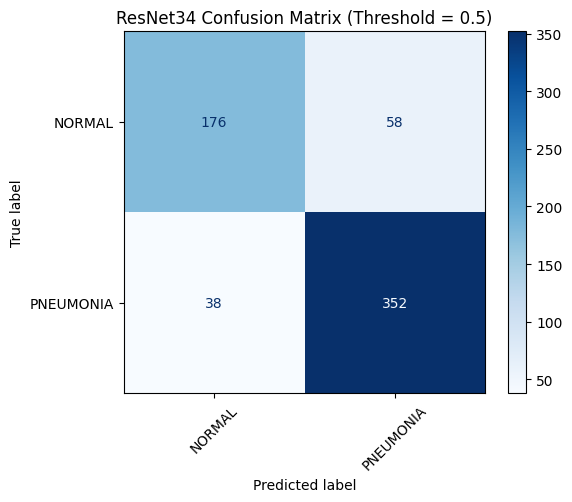

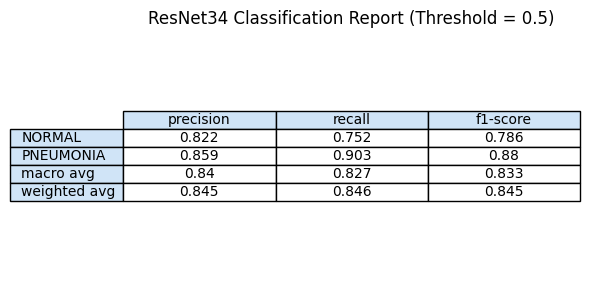

In [3]:
from pathlib import Path
from src.plot import plot_confusion_matrix, plot_classification_report
from sklearn.metrics import confusion_matrix, classification_report

FIG_DIR = Path(".") / "outputs" / MODEL_NAME # Should already exist from training history plot

cm = confusion_matrix(y_test_true, y_test_pred)
cr = classification_report(y_test_true, y_test_pred, target_names=CLASS_NAMES, output_dict=True)

plot_confusion_matrix(
    cm=cm, 
    classes=CLASS_NAMES, 
    fig_title=f"{MODEL_NAME} Confusion Matrix (Threshold = {THRESHOLD})", 
    fig_name=FIG_DIR / f"confusion_matrix_threshold_{THRESHOLD}.png")

plot_classification_report(
    cr=cr, 
    fig_title=f"{MODEL_NAME} Classification Report (Threshold = {THRESHOLD})", 
    fig_name=FIG_DIR / f"classification_report_threshold_{THRESHOLD}.png")

For clinical diagnosis, low false negative rate is the probably the desired type of bias, but we can observe the tradeoff between true positive rate and false positive rate (ROC curve) across a range of thresholds to see how the classifier's errors change.

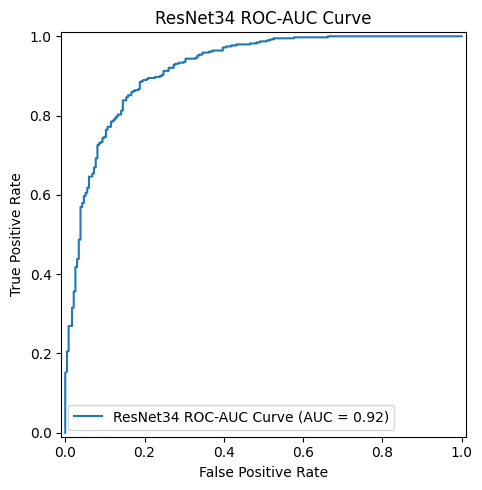

In [4]:
from src.plot import plot_roc_curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_true, y_test_proba)
roc_auc = auc(fpr, tpr)

plot_roc_curve(
    fpr=fpr, 
    tpr=tpr, 
    roc_auc=roc_auc, 
    fig_title=f"{MODEL_NAME} ROC-AUC Curve", 
    fig_name=FIG_DIR / "roc_auc_curve.png")

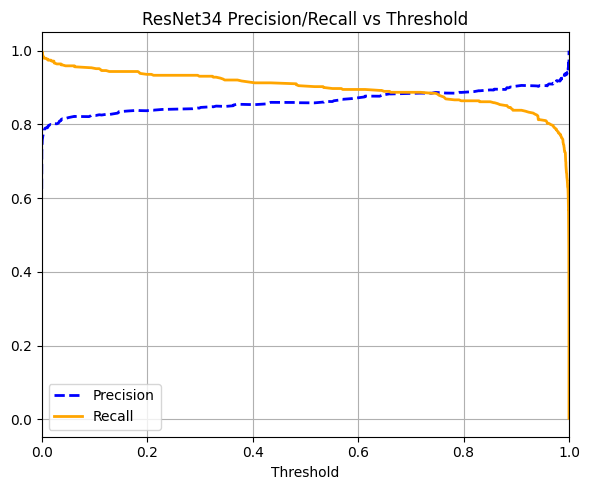

In [5]:
from src.plot import plot_precision_recall_curve
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test_true, y_test_proba)

plot_precision_recall_curve(
    precisions=precisions, 
    recalls=recalls, 
    thresholds=thresholds, 
    fig_title=f"{MODEL_NAME} Precision/Recall vs Threshold",  
    fig_name=FIG_DIR / "precision_recall_curve.png")

F1 represents the harmonic mean between precision and recall. We can find a threshold that maximises this score by computing it across all tresholds of the precision-recall curve.

In [6]:
from sklearn.metrics import f1_score

f1_scores = [f1_score(y_test_true, (y_test_proba > t).astype(int)) for t in thresholds]
F1_MAX_THRESHOLD = thresholds[np.argmax(f1_scores)]
F1_MAX_THRESHOLD = round(float(F1_MAX_THRESHOLD), 3)
F1_MAX_THRESHOLD

0.162

Now re-run inference using the adjusted threshold.

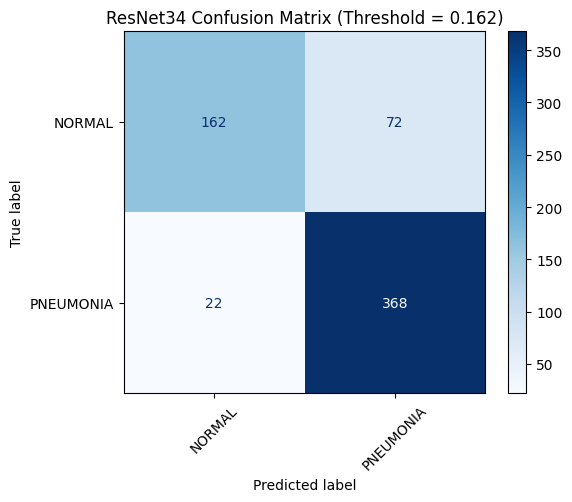

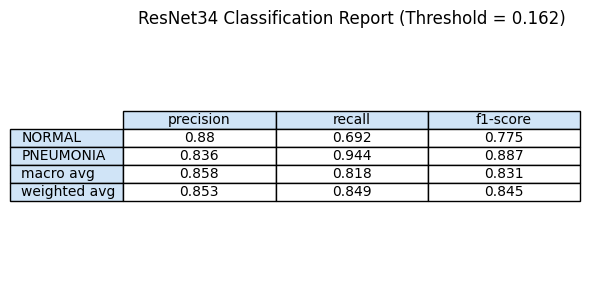

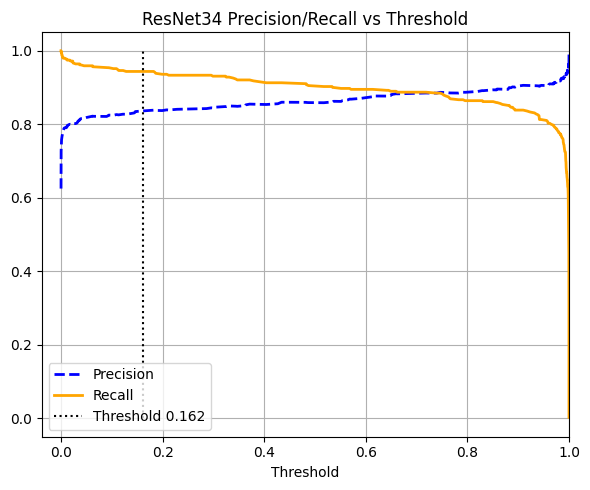

In [7]:
# Recompute the test set predictions using the new threshold
y_test_pred = (y_test_proba > F1_MAX_THRESHOLD).astype(int).flatten()

# Recompute the confusion matrix and classification report
cm = confusion_matrix(y_test_true, y_test_pred)
cr = classification_report(y_test_true, y_test_pred, target_names=CLASS_NAMES, output_dict=True)

plot_confusion_matrix(
    cm=cm, 
    classes=CLASS_NAMES, 
    fig_title=f"{MODEL_NAME} Confusion Matrix (Threshold = {F1_MAX_THRESHOLD})", 
    fig_name=FIG_DIR / f"confusion_matrix_threshold_{F1_MAX_THRESHOLD}.png")

plot_classification_report(
    cr=cr, 
    fig_title=f"{MODEL_NAME} Classification Report (Threshold = {F1_MAX_THRESHOLD})", 
    fig_name=FIG_DIR / f"classification_report_threshold_{F1_MAX_THRESHOLD}.png")

# Replot precision/recall vs threshold curve, with a tighter x axis and line at chosen threshold
plot_precision_recall_curve(
    precisions=precisions, 
    recalls=recalls, 
    thresholds=thresholds, 
    fig_title=f"{MODEL_NAME} Precision/Recall vs Threshold",
    fig_name=FIG_DIR / f"precision_recall_curve_threshold_{F1_MAX_THRESHOLD}.png",
    threshold=F1_MAX_THRESHOLD,
    bounds=[max(0.0, F1_MAX_THRESHOLD - 0.2), 1.0]) # NOTE: OR UPDATE WITHIN REASONABLE RANGE OF COMPUTED THRESHOLD